# Step 03: Exploratory Data Analysis (EDA)
## MandiMitra ML Pipeline: Maharashtra Daily Mandi Price Analysis (2024–2026)

**Objective:** Conduct an in-depth exploratory analysis of the combined Agmarknet Maharashtra price dataset (`data/processed/maharashtra_2024_2026_combined.csv`) to understand distributions, data quality, temporal patterns, and ML readiness.

**Constraints:**
- No modification of original CSV
- No dropping of rows or filling missing values
- No model training or synthetic data generation
- Explicit assessment of feature availability against MandiMitra decision support system requirements



### 0. Environment Setup and Data Loading


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

BASE_DIR = Path("..").resolve()
DATA_PATH = BASE_DIR / "data" / "processed" / "maharashtra_2024_2026_combined.csv"
OUTPUTS_DIR = BASE_DIR / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

df_raw = pd.read_csv(DATA_PATH)
print(f"Loaded dataset from: {DATA_PATH}")
print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")


Loaded dataset from: /Users/moksh/Desktop/MandiMitra-ML/data/processed/maharashtra_2024_2026_combined.csv
Shape: 8,909 rows x 12 columns


---
### 1. Dataset Overview
- Number of rows & columns
- Data types
- Date range and inspection



In [2]:
# Create working dataframe copy for exploratory analysis without modifying the file
df = df_raw.copy()

print("--- Data Types & Non-Null Counts ---")
print(df.info())

print("\n--- First 5 Records ---")
display(df.head(5))

print("\n--- Basic Column Value Summary ---")
for col in df.columns:
    print(f"Column: {col:<18} | Type: {str(df[col].dtype):<8} | Unique: {df[col].nunique():<5} | Sample: {str(df[col].iloc[0])}")



--- Data Types & Non-Null Counts ---
<class 'pandas.DataFrame'>
RangeIndex: 8909 entries, 0 to 8908
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   State/UT         8909 non-null   str  
 1   District         8909 non-null   str  
 2   Market           8909 non-null   str  
 3   Commodity Group  8909 non-null   str  
 4   Commodity        8909 non-null   str  
 5   Variety          8909 non-null   str  
 6   Grade            8909 non-null   str  
 7   Min Price        8909 non-null   str  
 8   Max Price        8909 non-null   str  
 9   Modal Price      8909 non-null   str  
 10  Price Unit       8909 non-null   str  
 11  Price Date       8909 non-null   str  
dtypes: str(12)
memory usage: 835.3 KB
None

--- First 5 Records ---


,State/UT,District,Market,Commodity Group,Commodity,Variety,Grade,Min Price,Max Price,Modal Price,Price Unit,Price Date
0,Maharashtra,Ahilyanagar,APMC Karjat,Cereals,Rice,Other,FAQ,"4,500.00","6,500.00","5,500.00",Rs./Quintal,2024-02-24
1,Maharashtra,Ahilyanagar,APMC Karjat,Cereals,Rice,Other,FAQ,"4,300.00","6,000.00","5,100.00",Rs./Quintal,2024-02-21
2,Maharashtra,Ahilyanagar,APMC Karjat,Cereals,Rice,Other,FAQ,"4,200.00","6,000.00","5,000.00",Rs./Quintal,2024-02-20
3,Maharashtra,Ahilyanagar,APMC Karjat,Cereals,Rice,Other,FAQ,"4,000.00","5,800.00","4,800.00",Rs./Quintal,2024-02-19
4,Maharashtra,Ahilyanagar,APMC Karjat,Cereals,Rice,Other,FAQ,"4,000.00","6,000.00","5,000.00",Rs./Quintal,2024-02-15



--- Basic Column Value Summary ---
Column: State/UT           | Type: str      | Unique: 1     | Sample: Maharashtra
Column: District           | Type: str      | Unique: 18    | Sample: Ahilyanagar
Column: Market             | Type: str      | Unique: 30    | Sample: APMC Karjat 
Column: Commodity Group    | Type: str      | Unique: 1     | Sample: Cereals
Column: Commodity          | Type: str      | Unique: 1     | Sample: Rice
Column: Variety            | Type: str      | Unique: 2     | Sample: Other
Column: Grade              | Type: str      | Unique: 2     | Sample: FAQ
Column: Min Price          | Type: str      | Unique: 386   | Sample: 4,500.00
Column: Max Price          | Type: str      | Unique: 534   | Sample: 6,500.00
Column: Modal Price        | Type: str      | Unique: 447   | Sample: 5,500.00
Column: Price Unit         | Type: str      | Unique: 1     | Sample: Rs./Quintal
Column: Price Date         | Type: str      | Unique: 965   | Sample: 2024-02-24


*Note: In the raw Agmarknet export, prices are formatted as comma-separated strings (e.g., `"4,500.00"`). For exploratory calculations, we parse numeric representations into auxiliary working columns while keeping original columns intact.*


In [3]:
# Helper columns for numerical analysis
df['Price Date'] = pd.to_datetime(df['Price Date'])
for p_col in ['Min Price', 'Max Price', 'Modal Price']:
    df[f"{p_col}_num"] = df[p_col].astype(str).str.replace(',', '', regex=False).astype(float)

min_date = df['Price Date'].min().strftime('%Y-%m-%d')
max_date = df['Price Date'].max().strftime('%Y-%m-%d')
print(f"Dataset Date Range: {min_date} to {max_date} (Span: {(df['Price Date'].max() - df['Price Date'].min()).days + 1} calendar days)")



Dataset Date Range: 2024-01-01 to 2026-09-03 (Span: 977 calendar days)


---
### 2. Categorical Analysis
Examining the categorical cardinality across all geographic, commodity, and variety dimensions.



In [4]:
cat_cols = ['State/UT', 'District', 'Market', 'Commodity Group', 'Commodity', 'Variety', 'Grade', 'Price Unit']

summary_cat = []
for c in cat_cols:
    uniques = df[c].dropna().unique()
    summary_cat.append({
        "Feature": c,
        "Unique Count": len(uniques),
        "Unique Values": list(uniques) if len(uniques) <= 10 else f"{list(uniques[:5])} ... ({len(uniques)} total)"
    })

cat_df = pd.DataFrame(summary_cat)
display(cat_df)


,Feature,Unique Count,Unique Values
0,State/UT,1,[Maharashtra]
1,District,18,"['Ahilyanagar', 'Bhandara', 'Dharashiv', 'Dhul..."
2,Market,30,"['APMC Karjat ', 'APMC Sangamner ', 'APMC Bhan..."
3,Commodity Group,1,[Cereals]
4,Commodity,1,[Rice]
5,Variety,2,"[Other, 1009 Kar]"
6,Grade,2,"[FAQ, Local]"
7,Price Unit,1,[Rs./Quintal]


---
### 3. Market and District Distribution
Analyze the spatial observation volume across Maharashtra APMCs and districts.



Top 10 Markets by Observation Count:


,Observations
Market,
APMC Alibagh,950
APMC Murud,950
APMC Palghar,891
APMC Mangaon,765
APMC Solapur,719
APMC VASAI,681
APMC Ulhasnagar,653
APMC Karjat(Raigad),569
APMC Sangli,568



Bottom 10 Markets by Observation Count (Sparsity Risk):


,Observations
Market,
APMC Shirpur,20
APMC Navapur,18
APMC Sironcha,10
APMC Nandurbar,5
Nira(Saswad),5
APMC Sangamner,2
APMC Umarga,1
APMC Kandhar,1
APMC Varora,1



Records by District:


,Observations
District,
Raigad,3235
Palghar,1572
Thane,871
Solapur,719
Bhandara,716
Sangli,568
Nagpur,456
Pune,271
Mumbai,220


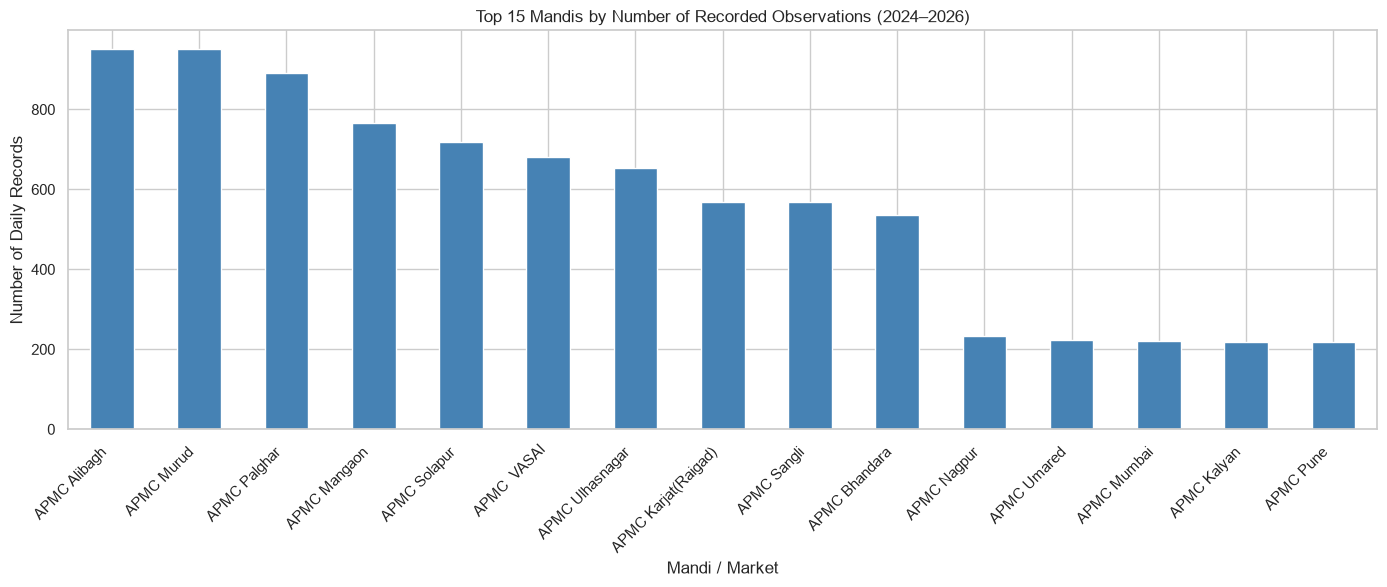

In [5]:
# Records per market
market_counts = df['Market'].value_counts()
print("Top 10 Markets by Observation Count:")
display(market_counts.head(10).to_frame(name="Observations"))

print("\nBottom 10 Markets by Observation Count (Sparsity Risk):")
display(market_counts.tail(10).to_frame(name="Observations"))

# Records per district
district_counts = df['District'].value_counts()
print("\nRecords by District:")
display(district_counts.to_frame(name="Observations"))

# Plot Market Volume
plt.figure(figsize=(14, 6))
market_counts.head(15).plot(kind='bar', color='steelblue')
plt.title("Top 15 Mandis by Number of Recorded Observations (2024–2026)")
plt.xlabel("Mandi / Market")
plt.ylabel("Number of Daily Records")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "top_markets_distribution.png", dpi=300)
plt.show()


---
### 4. Price Analysis
Summary statistics, distribution metrics, and extreme boundary detection for Min, Max, and Modal prices.



In [6]:
price_summary = df[['Min Price_num', 'Modal Price_num', 'Max Price_num']].describe().T
price_summary['median'] = df[['Min Price_num', 'Modal Price_num', 'Max Price_num']].median()
price_summary['skewness'] = df[['Min Price_num', 'Modal Price_num', 'Max Price_num']].skew()
price_summary['kurtosis'] = df[['Min Price_num', 'Modal Price_num', 'Max Price_num']].kurtosis()

display(price_summary[['count', 'mean', 'std', 'min', '25%', 'median', '75%', 'max', 'skewness', 'kurtosis']])

print(f"Minimum Observed Price in Dataset: Rs. {df['Min Price_num'].min():,.2f} / Quintal")
print(f"Maximum Observed Price in Dataset: Rs. {df['Max Price_num'].max():,.2f} / Quintal")
print(f"Modal Price Range: Rs. {df['Modal Price_num'].min():,.2f} to Rs. {df['Modal Price_num'].max():,.2f} / Quintal")

# Check extreme boundaries
print("\nExtreme Low Observations (Modal Price < Rs. 1000):")
display(df[df['Modal Price_num'] < 1000][['Price Date', 'District', 'Market', 'Variety', 'Min Price_num', 'Modal Price_num', 'Max Price_num']])

print("\nExtreme High Observations (Modal Price > Rs. 9000):")
display(df[df['Modal Price_num'] > 9000][['Price Date', 'District', 'Market', 'Variety', 'Min Price_num', 'Modal Price_num', 'Max Price_num']])



,count,mean,std,min,25%,median,75%,max,skewness,kurtosis
Min Price_num,8909.0,3453.780896,1165.555394,100.0,2500.0,3500.0,4100.0,8500.0,0.360427,1.38176
Modal Price_num,8909.0,4223.311483,1462.004361,280.0,3500.0,4150.0,5000.0,11100.0,0.727236,2.30037
Max Price_num,8909.0,5083.457178,2030.723252,280.0,3800.0,4800.0,6000.0,15000.0,0.633759,0.46160


Minimum Observed Price in Dataset: Rs. 100.00 / Quintal
Maximum Observed Price in Dataset: Rs. 15,000.00 / Quintal
Modal Price Range: Rs. 280.00 to Rs. 11,100.00 / Quintal

Extreme Low Observations (Modal Price < Rs. 1000):


,Price Date,District,Market,Variety,Min Price_num,Modal Price_num,Max Price_num
3952,2025-01-05,Palghar,APMC Palghar,1009 Kar,280.0,280.0,280.0



Extreme High Observations (Modal Price > Rs. 9000):


,Price Date,District,Market,Variety,Min Price_num,Modal Price_num,Max Price_num
3165,2025-12-30,Mumbai,APMC Mumbai,Other,6000.0,9250.0,10200.0
3167,2025-12-26,Mumbai,APMC Mumbai,Other,6000.0,9250.0,10200.0
3168,2025-12-25,Mumbai,APMC Mumbai,Other,6000.0,9250.0,10200.0
3171,2025-12-22,Mumbai,APMC Mumbai,Other,6000.0,9250.0,10200.0
3172,2025-12-19,Mumbai,APMC Mumbai,Other,6000.0,9250.0,10200.0
...,...,...,...,...,...,...,...
7385,2026-01-07,Pune,APMC Pune,Other,7100.0,9650.0,12200.0
8600,2026-09-01,Thane,APMC Kalyan,Other,8200.0,9200.0,10200.0
8606,2026-08-24,Thane,APMC Kalyan,Other,8200.0,9200.0,10200.0
8607,2026-08-23,Thane,APMC Kalyan,Other,8200.0,9200.0,10200.0


---
### 5. Price Consistency Validation
Validate the logical business invariant:
$$\text{Min Price} \le \text{Modal Price} \le \text{Max Price}$$



In [7]:
violation_min_modal = df['Min Price_num'] > df['Modal Price_num']
violation_modal_max = df['Modal Price_num'] > df['Max Price_num']
any_violation = violation_min_modal | violation_modal_max

n_violations = any_violation.sum()
pct_violations = (n_violations / len(df)) * 100

print(f"Total Records Evaluated : {len(df):,}")
print(f"Price Invariant Violations: {n_violations} ({pct_violations:.2f}%)")
print(f"Min > Modal Violations   : {violation_min_modal.sum()}")
print(f"Modal > Max Violations   : {violation_modal_max.sum()}")

if n_violations > 0:
    print("\nSample Invariant Violations:")
    display(df[any_violation][['Price Date', 'Market', 'Variety', 'Min Price_num', 'Modal Price_num', 'Max Price_num']].head())
else:
    print("\n[PASSED] 100% of records strictly satisfy: Min Price <= Modal Price <= Max Price.")


Total Records Evaluated : 8,909
Price Invariant Violations: 0 (0.00%)
Min > Modal Violations   : 0
Modal > Max Violations   : 0

[PASSED] 100% of records strictly satisfy: Min Price <= Modal Price <= Max Price.


---
### 6. Temporal Analysis
Observation frequency across years, calendar months, and days of the week.



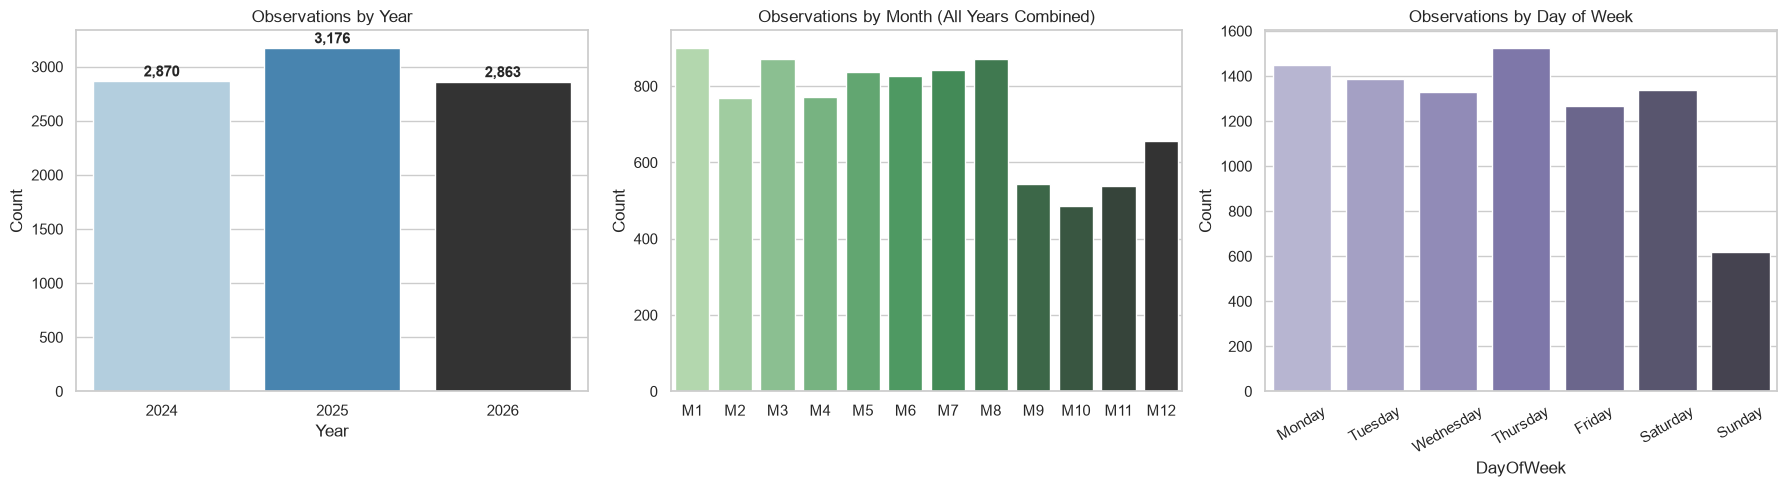

Observations by Year:


,Count
Year,
2024,2870
2025,3176
2026,2863



Observations by Day of Week:


,Count
DayOfWeek,
Monday,1448
Tuesday,1385
Wednesday,1327
Thursday,1526
Friday,1268
Saturday,1336
Sunday,619


In [8]:
df['Year'] = df['Price Date'].dt.year
df['Month'] = df['Price Date'].dt.month
df['Month_Name'] = df['Price Date'].dt.strftime('%b')
df['DayOfWeek'] = df['Price Date'].dt.day_name()
df['Day'] = df['Price Date'].dt.day

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Observations by Year
year_counts = df['Year'].value_counts().sort_index()
sns.barplot(x=year_counts.index, y=year_counts.values, ax=axes[0], hue=year_counts.index, palette="Blues_d", legend=False)
axes[0].set_title("Observations by Year")
axes[0].set_ylabel("Count")
for i, v in enumerate(year_counts.values):
    axes[0].text(i, v + 40, f"{v:,}", ha='center', fontweight='bold')

# Observations by Month
month_counts = df.groupby('Month')['Price Date'].count()
sns.barplot(x=[f"M{m}" for m in month_counts.index], y=month_counts.values, ax=axes[1], hue=month_counts.index, palette="Greens_d", legend=False)
axes[1].set_title("Observations by Month (All Years Combined)")
axes[1].set_ylabel("Count")

# Observations by Day of Week
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_counts = df['DayOfWeek'].value_counts().reindex(dow_order)
sns.barplot(x=dow_counts.index, y=dow_counts.values, ax=axes[2], hue=dow_counts.index, palette="Purples_d", legend=False)
axes[2].set_title("Observations by Day of Week")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "temporal_observations.png", dpi=300)
plt.show()

print("Observations by Year:")
display(year_counts.to_frame(name="Count"))
print("\nObservations by Day of Week:")
display(dow_counts.to_frame(name="Count"))


---
### 7. Missing Values Analysis



In [9]:
missing_summary = pd.DataFrame({
    'Missing Count': df_raw.isnull().sum(),
    'Missing %': (df_raw.isnull().sum() / len(df_raw)) * 100
})
display(missing_summary)
print(f"Total missing values across entire raw combined dataset: {df_raw.isnull().sum().sum()}")


,Missing Count,Missing %
State/UT,0,0.0
District,0,0.0
Market,0,0.0
Commodity Group,0,0.0
Commodity,0,0.0
Variety,0,0.0
Grade,0,0.0
Min Price,0,0.0
Max Price,0,0.0
Modal Price,0,0.0


Total missing values across entire raw combined dataset: 0


---
### 8. Duplicate Analysis
Exact row-level duplicates and market-level multi-recording checks.



In [10]:
exact_duplicates = df_raw.duplicated().sum()
print(f"Exact Duplicate Rows across all columns: {exact_duplicates}")

# Multi-record checks on logical key (Market, Variety, Grade, Price Date)
key_cols = ['Market', 'Variety', 'Grade', 'Price Date']
key_duplicates = df.duplicated(subset=key_cols, keep=False).sum()
print(f"Records with duplicate key ({', '.join(key_cols)}): {key_duplicates}")

if key_duplicates > 0:
    print("\nSample duplicate key records:")
    display(df[df.duplicated(subset=key_cols, keep=False)].sort_values(key_cols).head(6)[key_cols + ['Min Price_num', 'Modal Price_num', 'Max Price_num']])



Exact Duplicate Rows across all columns: 0
Records with duplicate key (Market, Variety, Grade, Price Date): 0


---
### 9. Market × Variety Cross-Tabulation
Understanding commodity variety availability per APMC mandi.



Variety,1009 Kar,Other,Total
Market,,,
APMC VASAI,681,0,681
APMC Alibagh,0,950,950
APMC Baramati,0,48,48
APMC Bhandara,332,203,535
APMC Kalyan,0,218,218
APMC Kandhar,0,1,1
APMC Karjat,0,39,39
APMC Karjat(Raigad),0,569,569
APMC Khalapur (Shil-Phata),0,1,1


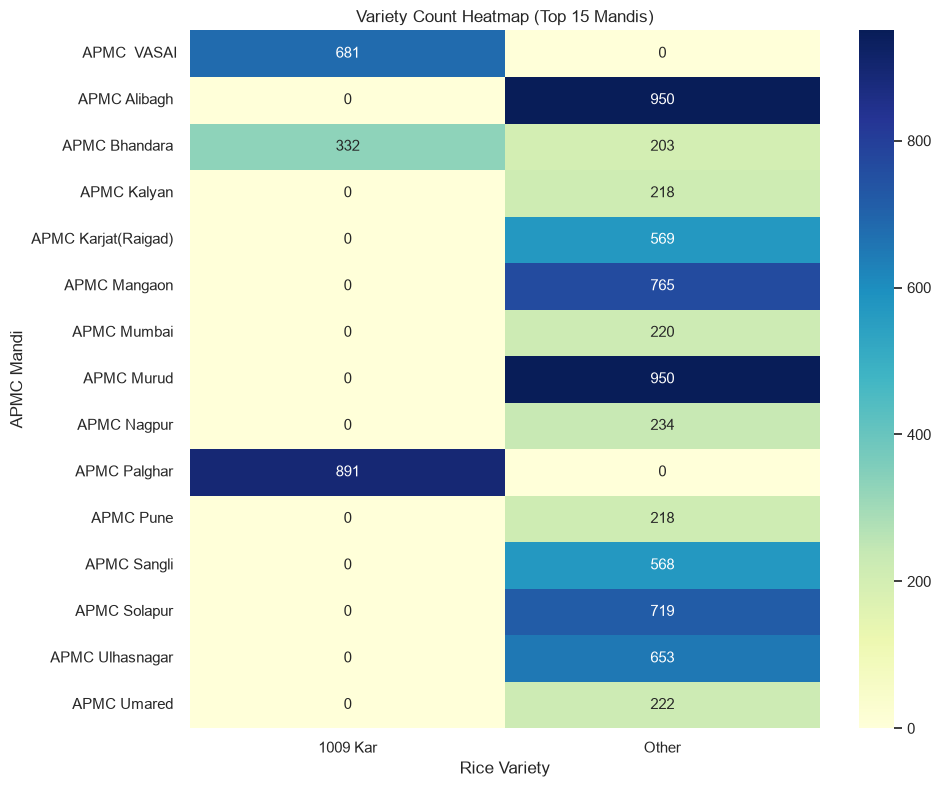

In [11]:
market_variety_ct = pd.crosstab(df['Market'], df['Variety'], margins=True, margins_name="Total")
display(market_variety_ct)

# Heatmap visualization of top 15 markets
plt.figure(figsize=(10, 8))
top15_markets = df['Market'].value_counts().head(15).index
ct_top15 = pd.crosstab(df[df['Market'].isin(top15_markets)]['Market'], df['Variety'])
sns.heatmap(ct_top15, annot=True, fmt="d", cmap="YlGnBu", cbar=True)
plt.title("Variety Count Heatmap (Top 15 Mandis)")
plt.ylabel("APMC Mandi")
plt.xlabel("Rice Variety")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "market_variety_heatmap.png", dpi=300)
plt.show()


---
### 10. Market Price Comparison
Comparative price level statistics by APMC market.



,Observations,Average,Median,Min,Max,Std_Dev
Market,,,,,,
APMC Alibagh,950,"₹2,544.95","₹2,600.00","₹1,200.00","₹4,250.00",₹876.13
APMC Murud,950,"₹2,545.42","₹2,600.00","₹1,200.00","₹4,250.00",₹874.68
APMC Palghar,891,"₹4,519.52","₹4,500.00",₹280.00,"₹6,201.00",₹543.56
APMC Mangaon,765,"₹3,709.67","₹3,800.00","₹3,200.00","₹4,700.00",₹163.76
APMC Solapur,719,"₹3,947.49","₹3,965.00","₹3,240.00","₹4,500.00",₹158.45
APMC VASAI,681,"₹4,048.63","₹3,965.00","₹3,350.00","₹4,650.00",₹296.58
APMC Ulhasnagar,653,"₹4,599.46","₹4,500.00","₹3,250.00","₹6,000.00",₹427.65
APMC Karjat(Raigad),569,"₹5,035.06","₹5,100.00","₹2,350.00","₹6,000.00",₹245.53
APMC Sangli,568,"₹6,211.90","₹6,250.00","₹4,500.00","₹7,000.00",₹482.09


/var/folders/y0/vfsdrz8966q3gtjq4bh4v6h00000gn/T/ipykernel_4383/1913365137.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['Market'].isin(top8_markets)], x='Market', y='Modal Price_num', palette='Set3')
/var/folders/y0/vfsdrz8966q3gtjq4bh4v6h00000gn/T/ipykernel_4383/1913365137.py:27: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/y0/vfsdrz8966q3gtjq4bh4v6h00000gn/T/ipykernel_4383/1913365137.py:28: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig(OUTPUTS_DIR / "market_price_boxplots.png", dpi=300)
/Users/moksh/Desktop/MandiMitra-ML/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


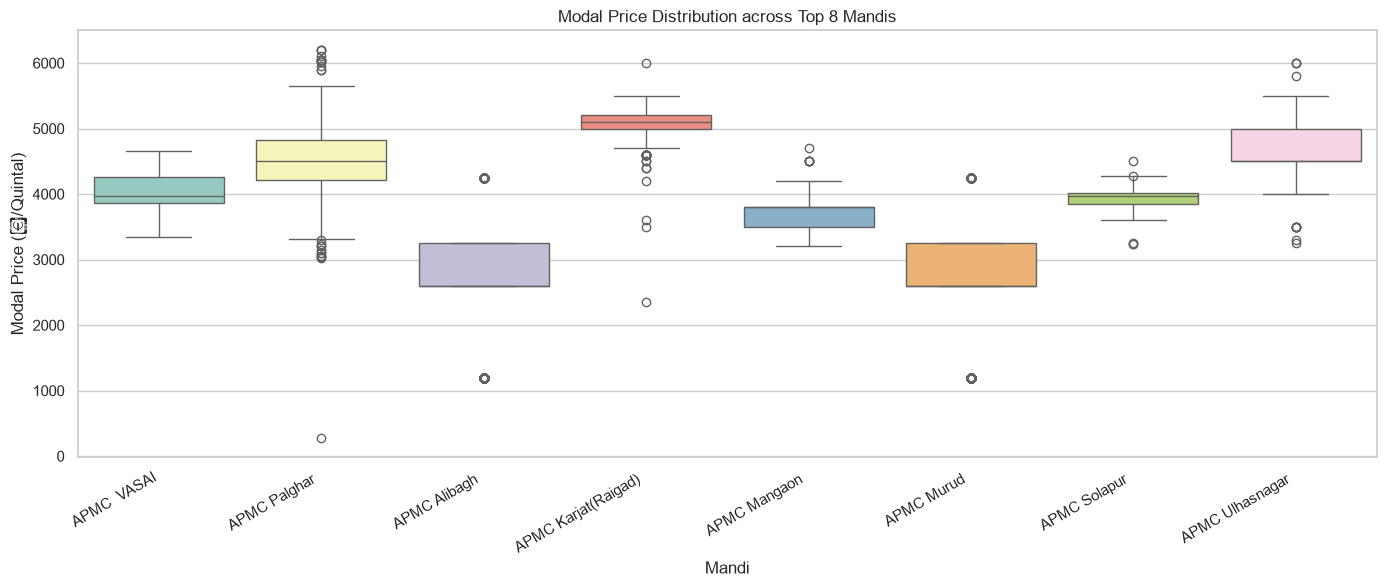

In [12]:
market_stats = df.groupby('Market')['Modal Price_num'].agg(
    Observations='count',
    Average='mean',
    Median='median',
    Min='min',
    Max='max',
    Std_Dev='std'
).sort_values(by='Observations', ascending=False)

display(market_stats.style.format({
    'Observations': '{:,.0f}',
    'Average': '₹{:,.2f}',
    'Median': '₹{:,.2f}',
    'Min': '₹{:,.2f}',
    'Max': '₹{:,.2f}',
    'Std_Dev': '₹{:,.2f}'
}))

# Boxplot comparing modal prices in top 8 markets
top8_markets = market_stats.head(8).index
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[df['Market'].isin(top8_markets)], x='Market', y='Modal Price_num', palette='Set3')
plt.title("Modal Price Distribution across Top 8 Mandis")
plt.xlabel("Mandi")
plt.ylabel("Modal Price (₹/Quintal)")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "market_price_boxplots.png", dpi=300)
plt.show()


---
### 11. Time-Series Visualization
Visualizing historical price trends, volatility, and distribution across time.



/var/folders/y0/vfsdrz8966q3gtjq4bh4v6h00000gn/T/ipykernel_4383/1035164390.py:41: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/y0/vfsdrz8966q3gtjq4bh4v6h00000gn/T/ipykernel_4383/1035164390.py:42: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.savefig(OUTPUTS_DIR / "time_series_and_distributions.png", dpi=300)


/Users/moksh/Desktop/MandiMitra-ML/venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


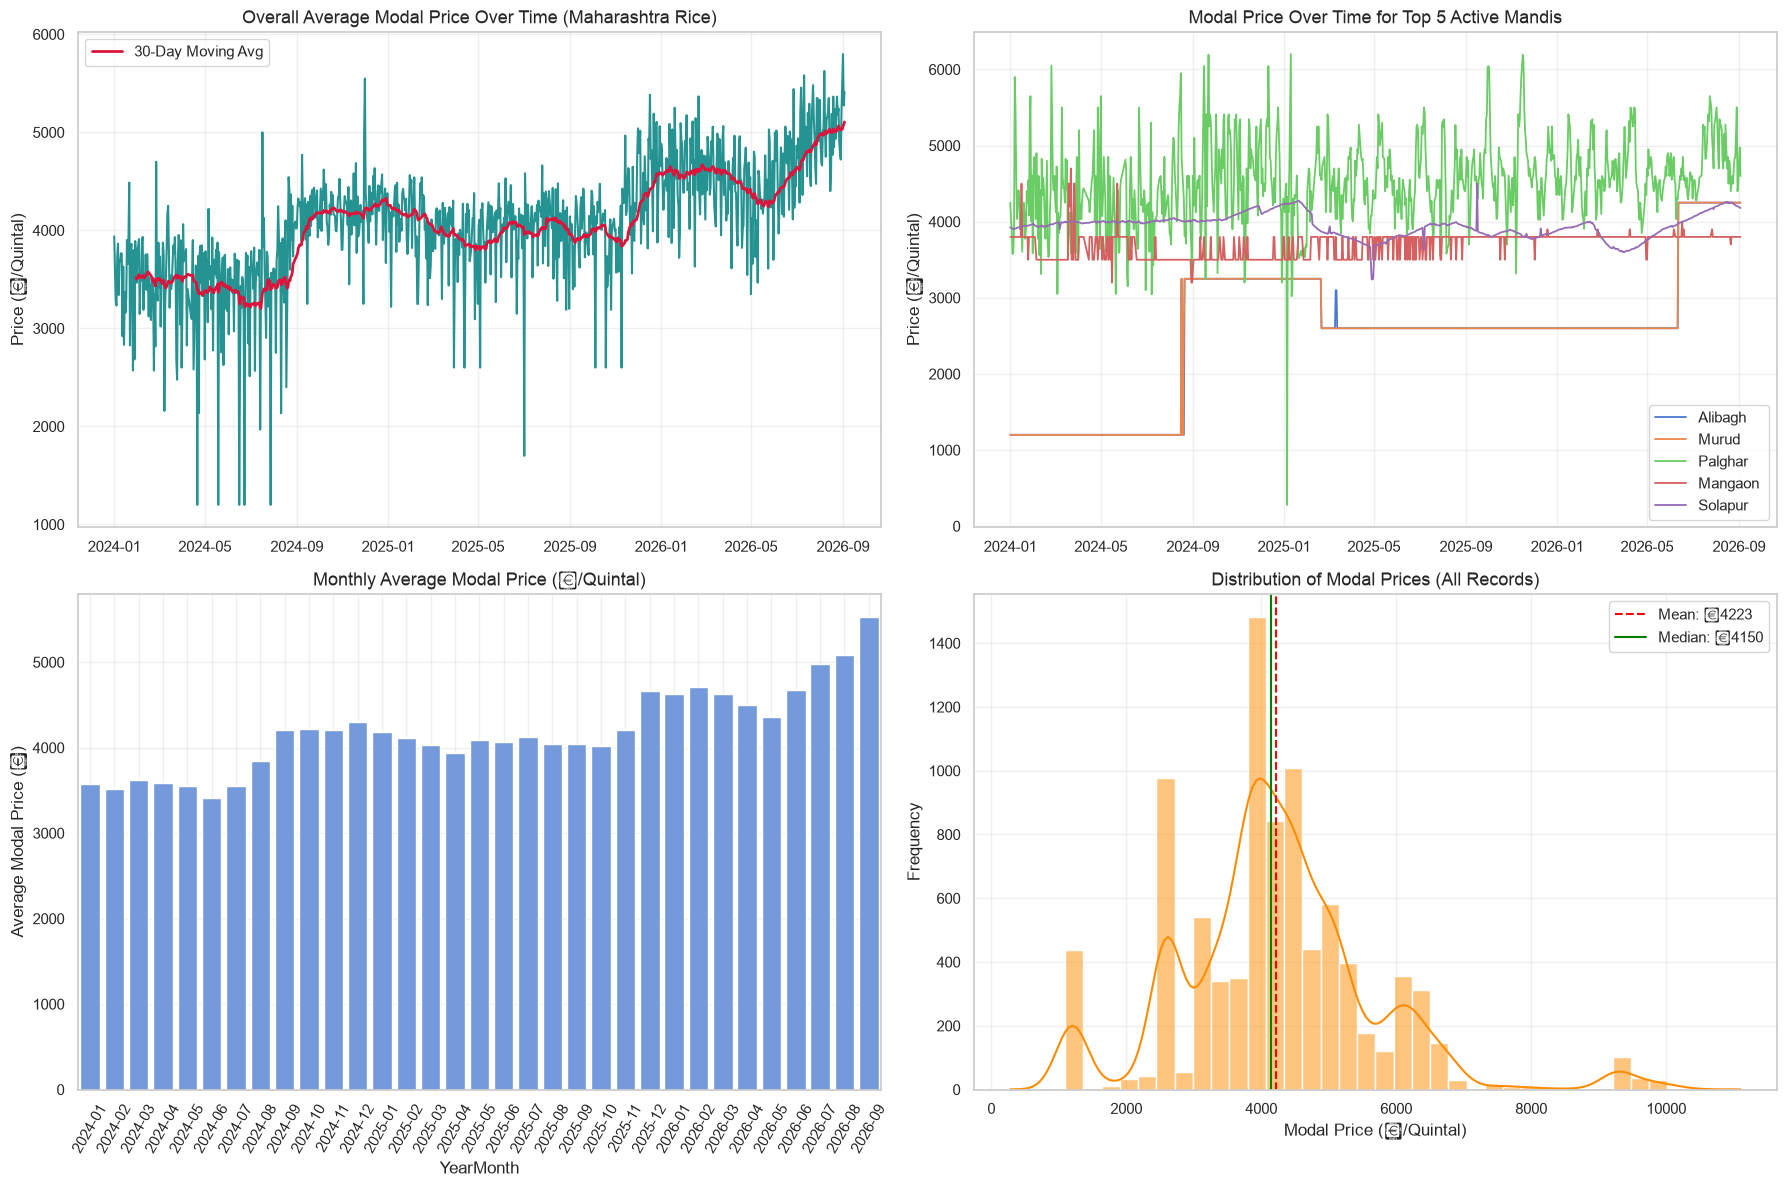

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 11.1 Overall Average Modal Price Over Time (Daily)
daily_overall = df.groupby('Price Date')['Modal Price_num'].mean().reset_index()
axes[0, 0].plot(daily_overall['Price Date'], daily_overall['Modal Price_num'], color='teal', lw=1.5, alpha=0.85)
axes[0, 0].plot(daily_overall['Price Date'], daily_overall['Modal Price_num'].rolling(30).mean(), color='crimson', lw=2, label='30-Day Moving Avg')
axes[0, 0].set_title("Overall Average Modal Price Over Time (Maharashtra Rice)", fontsize=13)
axes[0, 0].set_ylabel("Price (₹/Quintal)")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 11.2 Modal Price Over Time for Top 5 Markets
top5_markets = df['Market'].value_counts().head(5).index
for m in top5_markets:
    m_data = df[df['Market'] == m].groupby('Price Date')['Modal Price_num'].mean()
    axes[0, 1].plot(m_data.index, m_data.values, lw=1.3, label=m.replace('APMC ', ''))
axes[0, 1].set_title("Modal Price Over Time for Top 5 Active Mandis", fontsize=13)
axes[0, 1].set_ylabel("Price (₹/Quintal)")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 11.3 Monthly Average Modal Price
df['YearMonth'] = df['Price Date'].dt.to_period('M').astype(str)
monthly_avg = df.groupby('YearMonth')['Modal Price_num'].mean()
sns.barplot(x=monthly_avg.index, y=monthly_avg.values, ax=axes[1, 0], color='cornflowerblue')
axes[1, 0].set_title("Monthly Average Modal Price (₹/Quintal)", fontsize=13)
axes[1, 0].set_ylabel("Average Modal Price (₹)")
axes[1, 0].tick_params(axis='x', rotation=60)
axes[1, 0].grid(True, alpha=0.3)

# 11.4 Distribution of Modal Prices (Histogram + KDE)
sns.histplot(df['Modal Price_num'], kde=True, ax=axes[1, 1], color='darkorange', bins=40)
axes[1, 1].axvline(df['Modal Price_num'].mean(), color='red', linestyle='--', label=f"Mean: ₹{df['Modal Price_num'].mean():.0f}")
axes[1, 1].axvline(df['Modal Price_num'].median(), color='green', linestyle='-', label=f"Median: ₹{df['Modal Price_num'].median():.0f}")
axes[1, 1].set_title("Distribution of Modal Prices (All Records)", fontsize=13)
axes[1, 1].set_xlabel("Modal Price (₹/Quintal)")
axes[1, 1].set_ylabel("Frequency")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "time_series_and_distributions.png", dpi=300)
plt.show()


---
### 12. Data Availability Assessment (Continuity & Temporal Gaps)
Assessing whether APMC markets possess unbroken daily observation sequences or irregular reporting intervals.



In [14]:
total_calendar_days = (df['Price Date'].max() - df['Price Date'].min()).days + 1

continuity_list = []
for m, group in df.groupby('Market'):
    unique_dates = group['Price Date'].drop_duplicates().sort_values()
    obs_count = len(unique_dates)
    market_span = (unique_dates.max() - unique_dates.min()).days + 1
    max_gap = unique_dates.diff().dt.days.max() if len(unique_dates) > 1 else np.nan
    coverage_pct = (obs_count / total_calendar_days) * 100
    
    continuity_list.append({
        'Market': m,
        'Active Days': obs_count,
        'Market Span (Days)': market_span,
        'Max Gap (Days)': max_gap,
        'Overall Coverage (%)': coverage_pct
    })

continuity_df = pd.DataFrame(continuity_list).sort_values('Active Days', ascending=False).reset_index(drop=True)
display(continuity_df.head(15))

print(f"Total Calendar Days in Study Period: {total_calendar_days} days")
print(f"Mandis with > 70% temporal coverage: {(continuity_df['Overall Coverage (%)'] >= 70).sum()} out of {len(continuity_df)}")
print(f"Mandis with < 10 total observations: {(continuity_df['Active Days'] < 10).sum()} out of {len(continuity_df)}")



,Market,Active Days,Market Span (Days),Max Gap (Days),Overall Coverage (%)
0,APMC Alibagh,949,977,5.0,97.134084
1,APMC Murud,949,977,5.0,97.134084
2,APMC Palghar,890,977,7.0,91.095189
3,APMC Mangaon,765,977,34.0,78.300921
4,APMC Solapur,719,977,9.0,73.592631
5,APMC VASAI,681,976,13.0,69.703173
6,APMC Ulhasnagar,653,977,19.0,66.837257
7,APMC Sangli,568,976,20.0,58.137155
8,APMC Karjat(Raigad),568,920,7.0,58.137155
9,APMC Bhandara,429,975,16.0,43.909928


Total Calendar Days in Study Period: 977 days
Mandis with > 70% temporal coverage: 5 out of 30
Mandis with < 10 total observations: 7 out of 30


---
### 13. MandiMitra Feature Availability Matrix
Explicit accounting of all critical variables required for the full MandiMitra Decision Support System versus current dataset availability.



In [15]:
feature_matrix = [
    {"Feature / Variable": "Current price", "Present in Dataset": "YES", "Details / Data Source": "Present via latest available daily record per mandi"},
    {"Feature / Variable": "Historical price", "Present in Dataset": "YES", "Details / Data Source": "Daily historical prices from 2024-01-01 to 2026-09-03"},
    {"Feature / Variable": "Modal price", "Present in Dataset": "YES", "Details / Data Source": "'Modal Price' column (₹/Quintal)"},
    {"Feature / Variable": "Min price", "Present in Dataset": "YES", "Details / Data Source": "'Min Price' column (₹/Quintal)"},
    {"Feature / Variable": "Max price", "Present in Dataset": "YES", "Details / Data Source": "'Max Price' column (₹/Quintal)"},
    {"Feature / Variable": "Arrival quantity", "Present in Dataset": "NO", "Details / Data Source": "NOT present in Agmarknet daily price report export"},
    {"Feature / Variable": "Weather", "Present in Dataset": "NO", "Details / Data Source": "NOT present (requires external meteorological API)"},
    {"Feature / Variable": "Transportation cost", "Present in Dataset": "NO", "Details / Data Source": "NOT present (requires logistics/fuel rate tables)"},
    {"Feature / Variable": "Distance", "Present in Dataset": "NO", "Details / Data Source": "NOT present (requires GIS/mandi geocoding)"},
    {"Feature / Variable": "Farmer location", "Present in Dataset": "NO", "Details / Data Source": "NOT present (client-side user input variable)"},
    {"Feature / Variable": "Demand", "Present in Dataset": "NO", "Details / Data Source": "NOT present in current records"},
    {"Feature / Variable": "Supply", "Present in Dataset": "NO", "Details / Data Source": "NOT present in current records"}
]

matrix_df = pd.DataFrame(feature_matrix)
display(matrix_df.style.set_properties(**{'text-align': 'left'}))


,Feature / Variable,Present in Dataset,Details / Data Source
0,Current price,YES,Present via latest available daily record per mandi
1,Historical price,YES,Daily historical prices from 2024-01-01 to 2026-09-03
2,Modal price,YES,'Modal Price' column (₹/Quintal)
3,Min price,YES,'Min Price' column (₹/Quintal)
4,Max price,YES,'Max Price' column (₹/Quintal)
5,Arrival quantity,NO,NOT present in Agmarknet daily price report export
6,Weather,NO,NOT present (requires external meteorological API)
7,Transportation cost,NO,NOT present (requires logistics/fuel rate tables)
8,Distance,NO,NOT present (requires GIS/mandi geocoding)
9,Farmer location,NO,NOT present (client-side user input variable)
